# Nuclear Waste Canister Temperature Prediction
**CIVIL-226 - Introduction to Machine Learning for Engineers — EPFL**

**Members:** CLERICI Alessandro | NAJA Nour

## Objectif
Prédire la température autour de conteneurs de déchets nucléaires à des positions de capteurs non observés,
en utilisant la puissance de chauffage, le temps, et les coordonnées spatiales des capteurs.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Imports OK')

Imports OK


## 2. Chargement des données

In [2]:
sensors = pd.read_parquet('data/sensors.parquet')
train   = pd.read_parquet('data/train.parquet')
test    = pd.read_parquet('data/test.parquet')

# Suppression des capteurs dupliqués (N206 et N213 — coordonnées identiques, erreur de reporting)
n_before = len(sensors)
sensors = sensors.drop_duplicates(subset='sensor', keep='first').reset_index(drop=True)
print(f'Doublons supprimés : {n_before - len(sensors)} (N206, N213)')

print(f'Sensors : {sensors.shape}  ->  {sensors.columns.tolist()}')
print(f'Train   : {train.shape}   ->  {train.columns.tolist()}')
print(f'Test    : {test.shape}    ->  {test.columns.tolist()}')

Doublons supprimés : 2 (N206, N213)
Sensors : (323, 4)  ->  ['sensor', 'coor_x', 'coor_y', 'coor_z']
Train   : (6626928, 4)   ->  ['sensor', 'time', 'power', 'temperature']
Test    : (2190480, 3)    ->  ['sensor', 'time', 'power']


## 3. Exploration des données (EDA)

In [3]:
print('=== SENSORS ===')
display(sensors.head())
print(f'\n{sensors["sensor"].nunique()} capteurs uniques')

print('\n=== TRAIN ===')
display(train.head())
print(f'\nValeurs manquantes :')
print(train.isnull().sum())

=== SENSORS ===


,sensor,coor_x,coor_y,coor_z
0,N2,0.5,0.0,0.0
1,N4,1.4,0.0,0.0
2,N5,0.5,2.4,0.0
3,N6,0.0,2.4,0.0
4,N7,0.0,3.5,0.0



323 capteurs uniques

=== TRAIN ===


,sensor,time,power,temperature
0,N102,0.0,1487.964722,17.514429
1,N102,864000.0,1487.288818,17.820795
2,N102,1728000.0,1486.612915,17.573187
3,N102,2592000.0,1485.936890,16.513235
4,N102,3456000.0,1485.260986,16.303427



Valeurs manquantes :
sensor             0
time               0
power              0
temperature    99403
dtype: int64


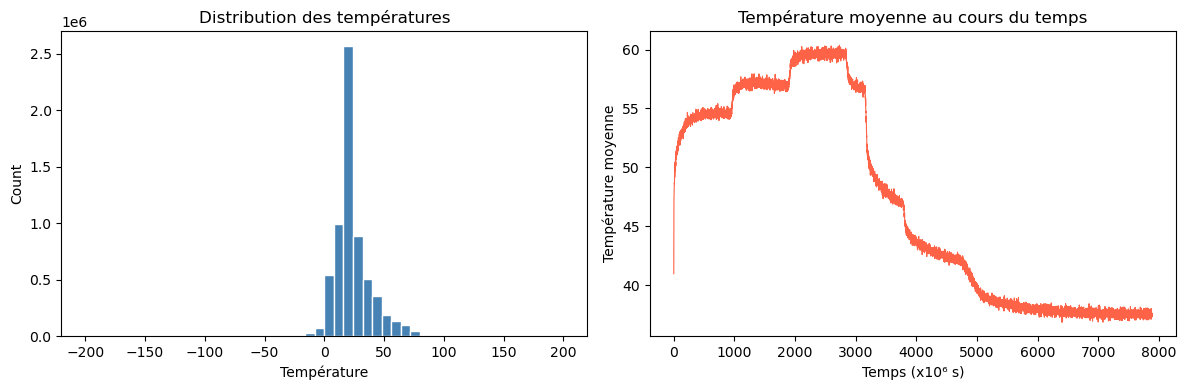

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['temperature'].dropna(), bins=50, color='steelblue',
             edgecolor='white', range=(-200, 200))
axes[0].set_title('Distribution des températures')
axes[0].set_xlabel('Température'); axes[0].set_ylabel('Count')

temp_by_time = train.groupby('time')['temperature'].mean()
axes[1].plot(temp_by_time.index / 1e6, temp_by_time.values, color='tomato', linewidth=0.8)
axes[1].set_title('Température moyenne au cours du temps')
axes[1].set_xlabel('Temps (x10⁶ s)'); axes[1].set_ylabel('Température moyenne')

plt.tight_layout(); plt.show()

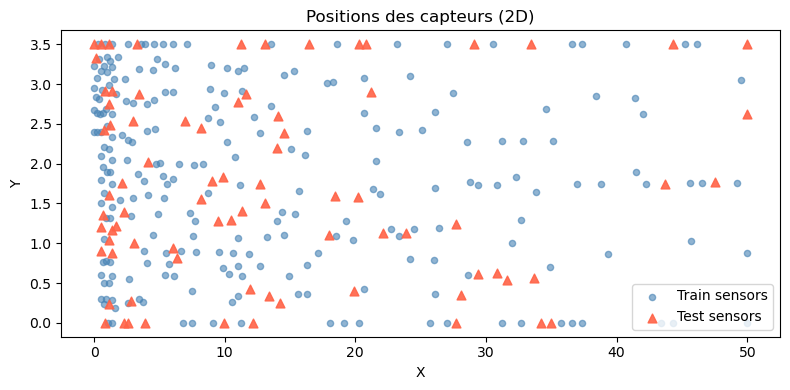

Capteurs train dans buffer (x<=1.4) : 56
Capteurs test dans buffer (x<=1.4)  : 18


In [5]:
train_sensors = set(train['sensor'].unique())
test_sensors  = set(test['sensor'].unique())
s_train = sensors[sensors['sensor'].isin(train_sensors)]
s_test  = sensors[sensors['sensor'].isin(test_sensors)]

plt.figure(figsize=(8, 4))
plt.scatter(s_train['coor_x'], s_train['coor_y'], c='steelblue', s=20, alpha=0.6, label='Train sensors')
plt.scatter(s_test['coor_x'],  s_test['coor_y'],  c='tomato', s=40, alpha=0.9, marker='^', label='Test sensors')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('Positions des capteurs (2D)')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Capteurs train dans buffer (x<=1.4) : {(s_train["coor_x"] <= 1.4).sum()}')
print(f'Capteurs test dans buffer (x<=1.4)  : {(s_test["coor_x"] <= 1.4).sum()}')

## 4. Preprocessing

### 4.1 Gestion des valeurs manquantes

Le train set contient ~99k valeurs manquantes. On les supprime car on ne peut pas les utiliser pour entraîner le modèle.

In [6]:
print(f'Lignes avant nettoyage : {len(train)}')
train_clean = train.dropna(subset=['temperature']).copy()
print(f'Après suppression NaN : {len(train_clean)}')
print(f'Supprimées : {len(train) - len(train_clean)} ({100*(len(train)-len(train_clean))/len(train):.1f}%)')

Lignes avant nettoyage : 6626928
Après suppression NaN : 6527525
Supprimées : 99403 (1.5%)


### 4.2 Feature Engineering

On joint les positions des capteurs au dataframe et on ajoute des features dérivées motivées
par la physique du transfert thermique :
- **dist_canister** : la température décroît avec la distance au canister
- **is_opa** : zone OPA pondérée plus fortement dans le score Kaggle
- **time_log** : capture la dynamique exponentielle du transfert thermique

In [7]:
def add_features(df, sensors_df):
    """
    Joint les coordonnées spatiales et ajoute des features dérivées.

    Features :
    - coor_x, coor_y : position spatiale (coor_z = 0 partout -> ignoré)
    - dist_center : distance à l'origine (r = sqrt(x²+y²))
    - dist_canister : distance au centre du canister (x=0.7, y=1.2)
    - is_opa : 1 si dans la zone OPA (x > 1.4), 0 si buffer
    - time_norm : temps normalisé entre 0 et 1
    - time_log : log(1+t) pour capturer la dynamique exponentielle
    - diffusion : terme de diffusion thermique exp(-r/sqrt(t)) / r
    - power_over_dist2 : puissance normalisée par distance² (loi en 1/r²)
    - diff_time : temps caractéristique de diffusion r²/t
    - exp_decay : atténuation exponentielle avec la distance
    """
    merged = df.merge(sensors_df, on='sensor', how='left')

    # Features spatiales
    merged['dist_center']   = np.sqrt(merged['coor_x']**2 + merged['coor_y']**2)
    merged['dist_canister'] = np.sqrt((merged['coor_x'] - 0.7)**2 + (merged['coor_y'] - 1.2)**2)
    merged['is_opa']        = (merged['coor_x'] > 1.4).astype(float)

    # Features temporelles
    t_max = train_clean['time'].max()
    merged['time_norm'] = merged['time'] / t_max
    merged['time_log']  = np.log1p(merged['time'])

    # Features physiques (loi de diffusion thermique)
    merged['diffusion']        = np.exp(-merged['dist_canister'] / (np.sqrt(merged['time'] + 1))) / (merged['dist_canister'] + 0.1)
    merged['power_over_dist2'] = merged['power'] / (merged['dist_canister']**2 + 0.01)
    merged['diff_time']        = merged['dist_canister']**2 / (merged['time_norm'] + 1e-6)
    merged['exp_decay']        = np.exp(-merged['dist_canister'] / 5.0)

    return merged

train_feat = add_features(train_clean, sensors)
test_feat  = add_features(test, sensors)

print('Features disponibles :', train_feat.columns.tolist())
display(train_feat.head(3))

Features disponibles : ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z', 'dist_center', 'dist_canister', 'is_opa', 'time_norm', 'time_log', 'diffusion', 'power_over_dist2', 'diff_time', 'exp_decay']


,sensor,time,power,temperature,coor_x,coor_y,coor_z,dist_center,dist_canister,is_opa,time_norm,time_log,diffusion,power_over_dist2,diff_time,exp_decay
0,N102,0.0,1487.964722,17.514429,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.000000,0.000000,3.847935e-22,0.719060,2.069309e+09,0.000112
1,N102,864000.0,1487.288818,17.820795,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.000110,13.669329,2.088718e-02,0.718734,1.871170e+07,0.000112
2,N102,1728000.0,1486.612915,17.573187,46.131474,3.5,0.0,46.264053,45.489655,1.0,0.000219,14.362476,2.118873e-02,0.718407,9.398341e+06,0.000112


In [ ]:
# Interpolation spatiale : températures des 3 capteurs train les plus proches
# Motivé par la continuité physique du champ thermique

def find_k_neighbors(pos_df, ref_pos_df, k, exclude_self=False):
    """Trouve les k capteurs les plus proches spatialement."""
    result = {}
    for s in pos_df.index:
        x, y = pos_df.loc[s, 'coor_x'], pos_df.loc[s, 'coor_y']
        dists = np.sqrt((ref_pos_df['coor_x'] - x)**2 + (ref_pos_df['coor_y'] - y)**2)
        if exclude_self and s in dists.index:
            dists = dists.drop(s)
        result[s] = dists.nsmallest(k).index.tolist()
    return result

def add_neighbor_temps(df, nbrs, temp_pivot):
    """
    Ajoute la température des 3 capteurs train les plus proches
    au même timestep — interpolation spatiale directe basée sur
    la continuité du champ thermique.
    """
    df = df.copy().reset_index(drop=True)
    t_idx = pd.Index(temp_pivot.index)
    s_idx = pd.Index(temp_pivot.columns)
    arr   = temp_pivot.values
    for i in range(3):
        nbr_map          = pd.Series({s: nbrs[s][i] for s in nbrs if s in df['sensor'].values})
        neighbor_sensors = df['sensor'].map(nbr_map).values
        time_vals        = df['time'].values
        row_ids = t_idx.get_indexer(time_vals)
        col_ids = s_idx.get_indexer(neighbor_sensors)
        temps = np.where(
            (row_ids >= 0) & (col_ids >= 0),
            arr[np.clip(row_ids, 0, len(arr)-1), np.clip(col_ids, 0, arr.shape[1]-1)],
            np.nan
        )
        df[f'temp_neighbor_{i+1}'] = temps
    # Remplir NaN avec médiane
    for i in range(3):
        col = f'temp_neighbor_{i+1}'
        df[col] = df[col].fillna(df[col].median())
    return df

# Positions des capteurs
sensor_pos = sensors.set_index('sensor')[['coor_x', 'coor_y']]
train_pos  = sensor_pos.loc[sensor_pos.index.isin(train_clean['sensor'].unique())]
test_pos   = sensor_pos.loc[sensor_pos.index.isin(test['sensor'].unique())]

# Calcul des voisins
print('Calcul des voisins...')
train_nbrs = find_k_neighbors(train_pos, train_pos, 5, exclude_self=True)
test_nbrs  = find_k_neighbors(test_pos,  train_pos, 5)

# Pivot table (rapide — ~2s pour tout le test set)
temp_pivot = train_clean.pivot_table(index='time', columns='sensor', values='temperature')
print(f'Pivot shape : {temp_pivot.shape}')

# Ajout des features voisines
train_feat = add_neighbor_temps(train_feat, train_nbrs, temp_pivot)
test_feat  = add_neighbor_temps(test_feat,  test_nbrs,  temp_pivot)

print(f'temp_neighbor NaN train : {train_feat["temp_neighbor_1"].isna().sum()}')
print(f'temp_neighbor NaN test  : {test_feat["temp_neighbor_1"].isna().sum()}')

Calcul des voisins...
Pivot shape : (9128, 242)
temp_neighbor NaN train : 0
temp_neighbor NaN test  : 0


In [ ]:
# Feature pondérée par la distance (interpolation de Shepard)
# Le voisin le plus proche pèse plus que les plus lointains

def add_weighted_neighbor(df, nbrs, temp_pivot, sensor_pos):
    """
    Température interpolée pondérée par 1/distance — plus physique
    que la simple moyenne des voisins.
    """
    df = df.copy().reset_index(drop=True)
    t_idx = pd.Index(temp_pivot.index)
    s_idx = pd.Index(temp_pivot.columns)
    arr   = temp_pivot.values

    weighted_temps = np.zeros(len(df))
    total_weights  = np.zeros(len(df))

    for i in range(3):
        nbr_map = pd.Series({s: nbrs[s][i] for s in nbrs if s in df['sensor'].values})
        neighbor_sensors = df['sensor'].map(nbr_map).values
        time_vals        = df['time'].values

        row_ids = t_idx.get_indexer(time_vals)
        col_ids = s_idx.get_indexer(neighbor_sensors)

        temps = np.where(
            (row_ids >= 0) & (col_ids >= 0),
            arr[np.clip(row_ids, 0, len(arr)-1), np.clip(col_ids, 0, arr.shape[1]-1)],
            np.nan
        )

        # Distance entre chaque point et son voisin i
        nbr_pos = sensor_pos.loc[neighbor_sensors.tolist() if hasattr(neighbor_sensors, 'tolist') else neighbor_sensors]
        dists = np.sqrt(
            (df['coor_x'].values - nbr_pos['coor_x'].values)**2 +
            (df['coor_y'].values - nbr_pos['coor_y'].values)**2
        ) + 0.01  # éviter division par zéro

        weights = 1 / dists
        valid   = ~np.isnan(temps)
        weighted_temps += np.where(valid, weights * temps, 0)
        total_weights  += np.where(valid, weights, 0)

    df['temp_weighted'] = np.where(total_weights > 0, weighted_temps / total_weights, np.nan)
    df['temp_weighted'] = df['temp_weighted'].fillna(df['temp_weighted'].median())
    return df

train_feat = add_weighted_neighbor(train_feat, train_nbrs, temp_pivot, sensor_pos)
test_feat  = add_weighted_neighbor(test_feat,  test_nbrs,  temp_pivot, sensor_pos)

print(f'temp_weighted NaN train : {train_feat["temp_weighted"].isna().sum()}')
print(f'temp_weighted NaN test  : {test_feat["temp_weighted"].isna().sum()}')

In [ ]:
TARGET = 'temperature'

FEATURES = ['coor_x', 'coor_y', 'time_norm', 'time_log', 'power',
            'dist_center', 'dist_canister', 'is_opa',
            'diffusion', 'power_over_dist2', 'diff_time', 'exp_decay',
            'temp_neighbor_1', 'temp_neighbor_2', 'temp_neighbor_3',
            'temp_weighted']
X = train_feat[FEATURES].values
y = train_feat[TARGET].values

print(f'X shape : {X.shape} — {len(FEATURES)} features')

X shape : (6527525, 15) — 15 features


### 4.3 Filtrage des aberrants & Split train/validation

In [11]:
# Filtrage des outliers AVANT le split pour éviter de contaminer la validation
mask_all = (y > -10) & (y < 200)
print(f'Aberrants supprimés : {(~mask_all).sum()} sur {len(y)}')
X_clean = X[mask_all]
y_clean = y[mask_all]

# Split 80/20
X_train, X_val, y_train, y_val = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Normalisation : fit sur train uniquement pour éviter le data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(test_feat[FEATURES].values)

assert len(X_test_s) == len(test)
print(f'Train : {X_train_s.shape} | Val : {X_val_s.shape} | Test : {X_test_s.shape}')

Aberrants supprimés : 108713 sur 6527525
Train : (5135049, 15) | Val : (1283763, 15) | Test : (2190480, 15)


## 5. Modèle — Random Forest

Extension des Decision Trees (lab svm_trees, section 3). Entraîne 100 arbres indépendants
en parallèle et moyenne leurs prédictions — robuste aux outliers, capture les interactions
non-linéaires entre position spatiale, temps et puissance.

$$\hat{y} = \frac{1}{T}\sum_{t=1}^{T} h_t(\mathbf{x})$$

où $h_t$ est le $t$-ième arbre de décision.

In [12]:
np.random.seed(42)
idx_rf = np.random.choice(len(X_train_s), size=200_000, replace=False)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_s[idx_rf], y_train[idx_rf])

y_pred_val_rf = rf.predict(X_val_s)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_val_rf))
print(f'Random Forest — RMSE validation : {rmse_rf:.4f}')

Random Forest — RMSE validation : 4.3770


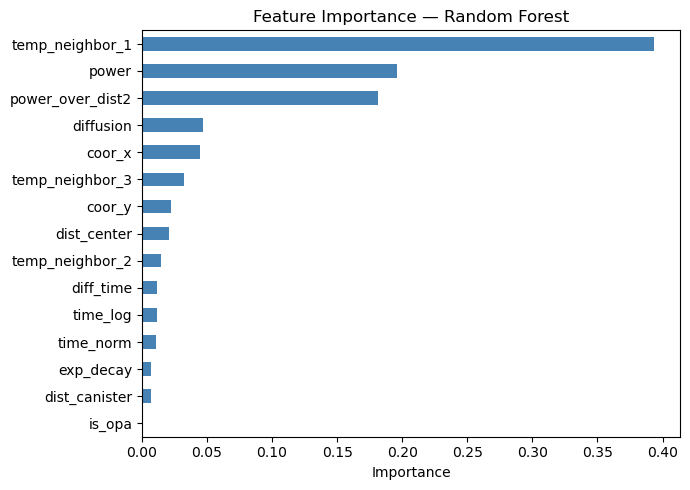

In [13]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Prédictions finales & Soumission

In [14]:
y_pred = rf.predict(X_test_s)

submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_pred.astype(float)
})

assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'Random Forest — RMSE validation : {rmse_rf:.4f}')
print(f'submission.csv sauvegardé — {len(submission)} lignes')
display(submission.head())

Random Forest — RMSE validation : 4.3770
submission.csv sauvegardé — 2190480 lignes


,Id,temperature
0,0,16.748659
1,1,17.563400
2,2,18.179713
3,3,17.602294
4,4,17.637218


In [ ]:
# Comparaison train vs prédictions par timestep
test_with_pred = test.copy()
test_with_pred['temperature_pred'] = y_pred

temp_train = train_clean.groupby('time')['temperature'].mean()
temp_pred  = test_with_pred.groupby('time')['temperature_pred'].mean()

plt.figure(figsize=(10, 4))
plt.plot(temp_train.index / 1e6, temp_train.values,
         label='Train (vraies)', color='tomato', alpha=0.7, linewidth=0.8)
plt.plot(temp_pred.index / 1e6, temp_pred.values,
         label='Test (prédites)', color='steelblue', alpha=0.7, linewidth=0.8)
plt.title('Comparaison train vs prédictions')
plt.xlabel('Temps (x10⁶ s)')
plt.ylabel('Température moyenne')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Pistes d'amélioration

- **Features supplémentaires** : `inv_dist_canister`, `coor_x_squared`, interactions distance-temps
- **Plus de données** : augmenter le sample au-delà de 200k
- **Deep Learning** : réseau de neurones sur GPU (Google Colab)
- **Interpolation spatiale** : température du capteur voisin comme feature